# IMDB Sentiment Classification
## NLP Classification for Movie Reviews

Film Junky Union needs an automated system to classify IMDB reviews as positive or negative. The project compares text normalization and TF-IDF pipelines with Logistic Regression and LightGBM, and also explores BERT embeddings under limited computational resources.

**Target:** F1 ≥ 0.85 on the test set.  
**Selected portfolio result:** NLTK + TF-IDF + Logistic Regression achieved **F1 = 0.88** and **ROC-AUC = 0.95**.

In [ ]:
from pathlib import Path

# Works when the kernel starts at the repository root or inside notebooks/.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), Path.cwd().parent)
     if (p / 'data').is_dir() and (p / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository root or notebooks/ directory.')
DATA_DIR = PROJECT_ROOT / 'data'


## Inicialização

In [37]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [38]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

sns.set_theme()

In [39]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [40]:
df_reviews = pd.read_csv(DATA_DIR / 'imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [41]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [42]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

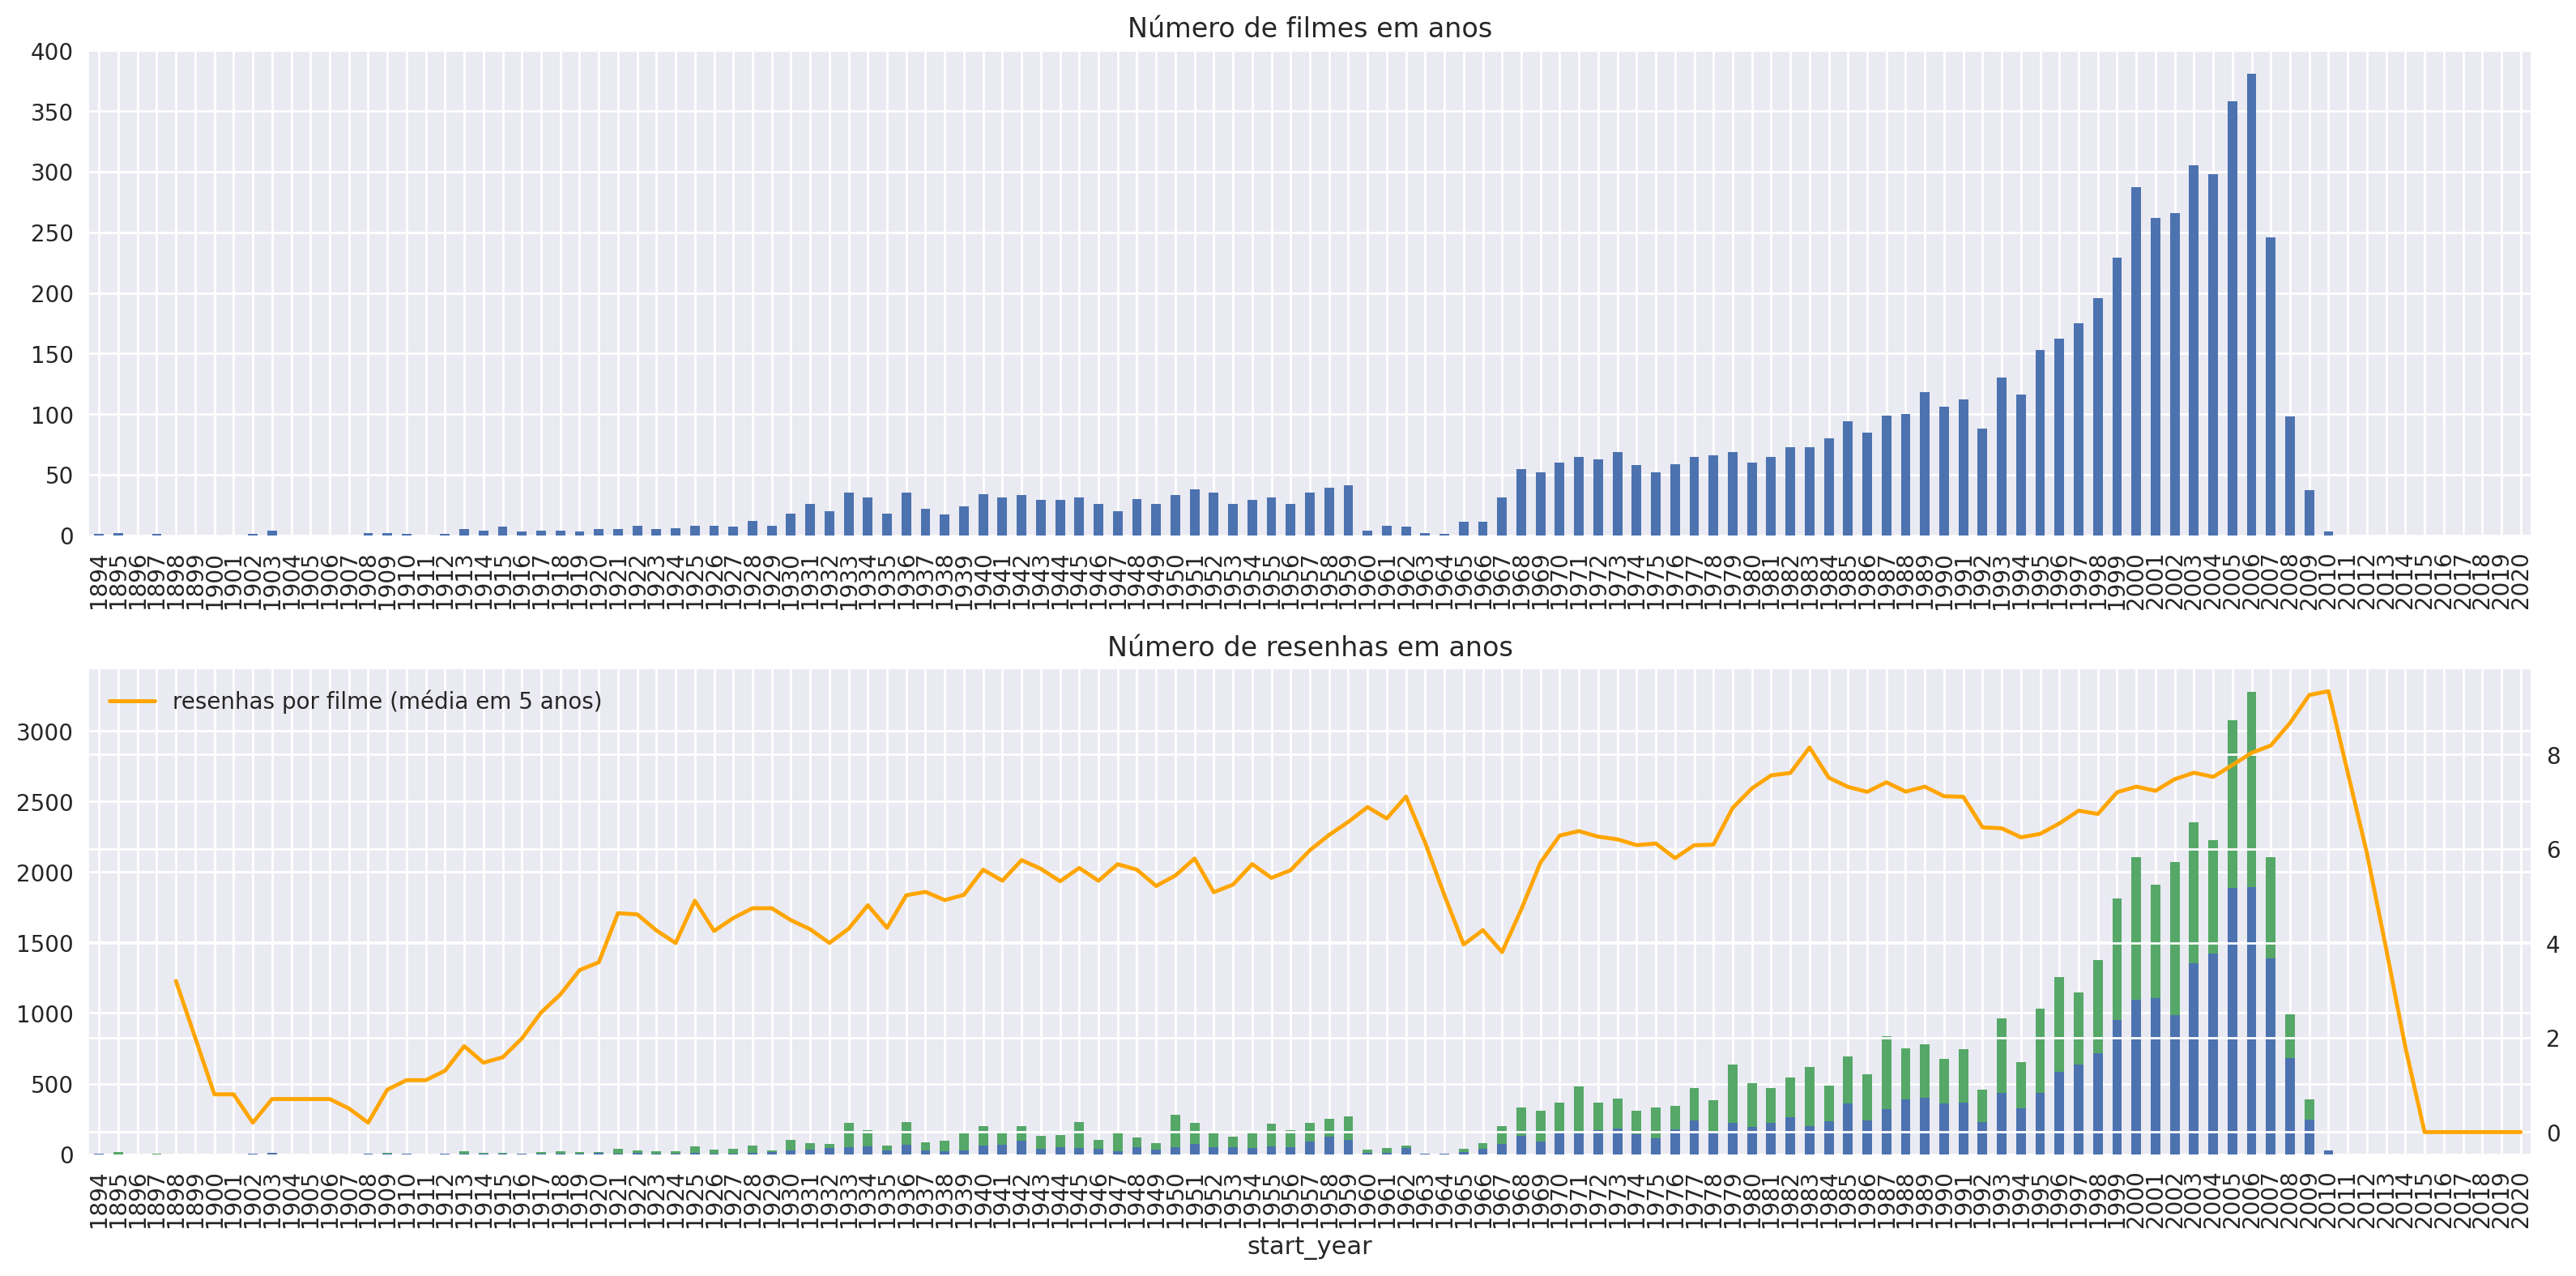

In [43]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

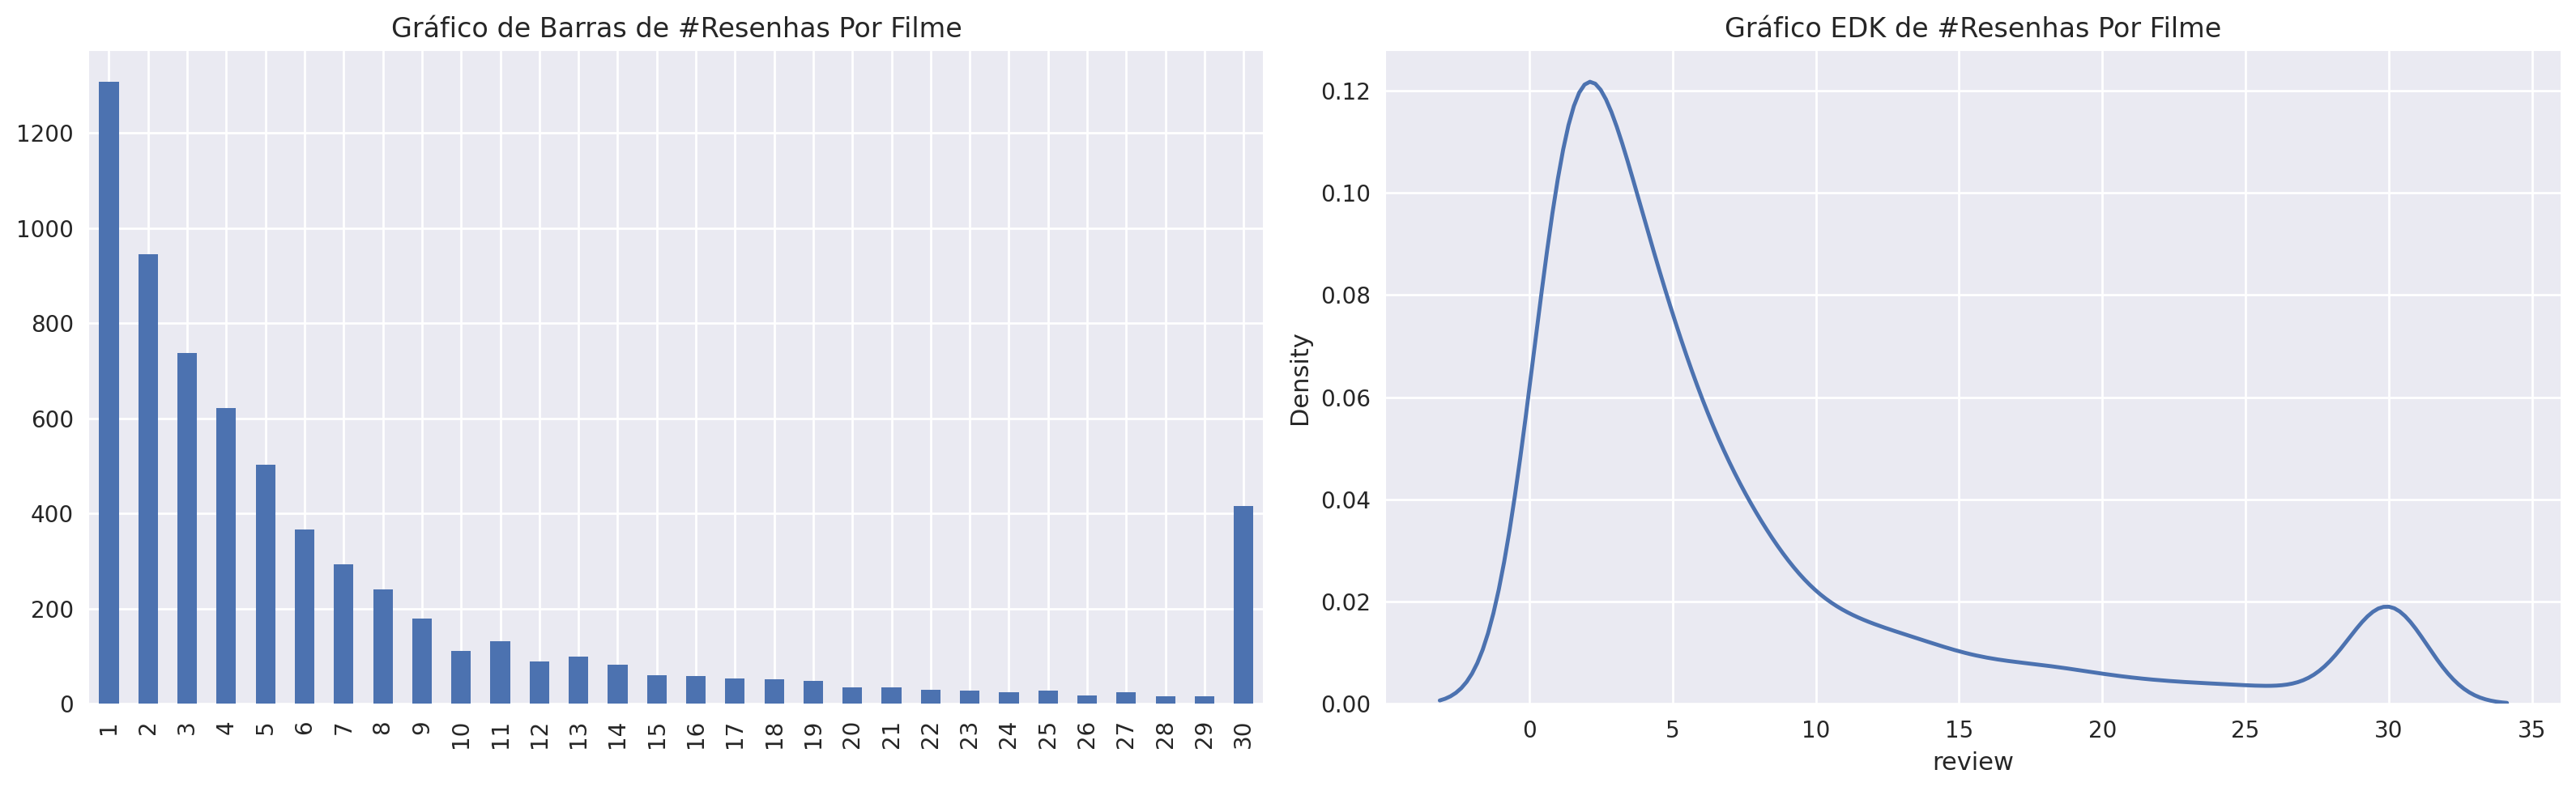

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

In [45]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

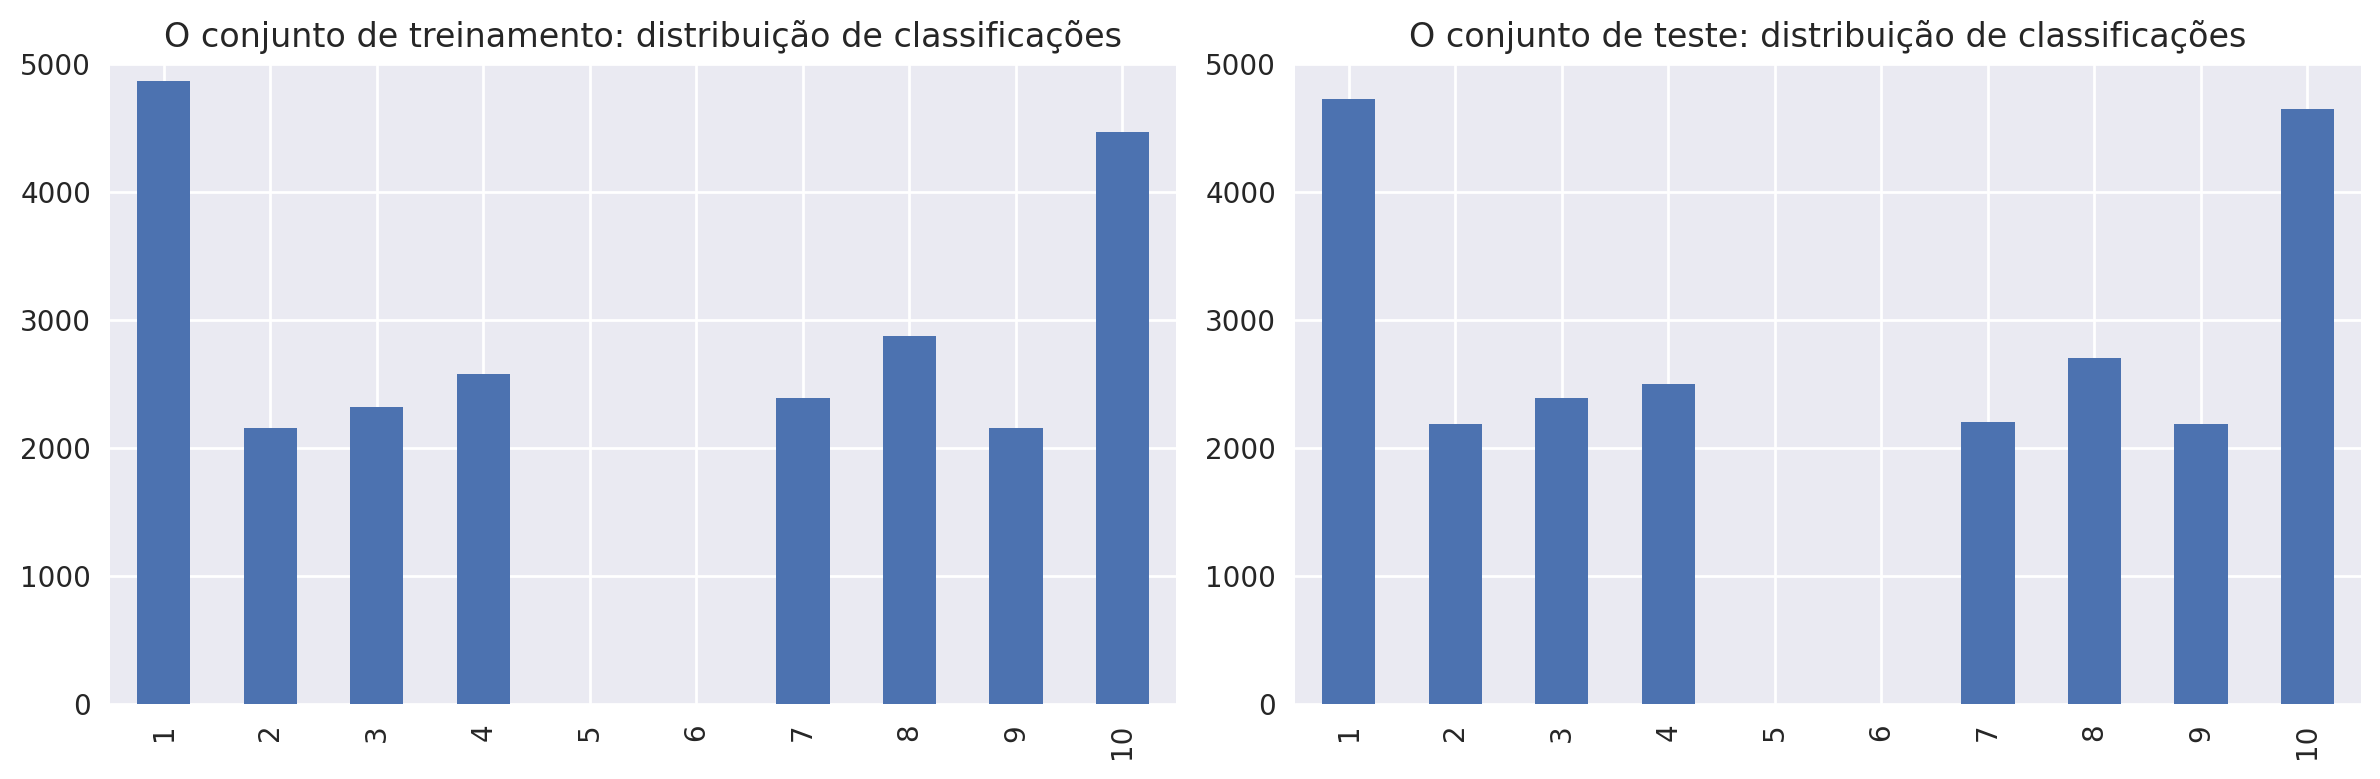

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


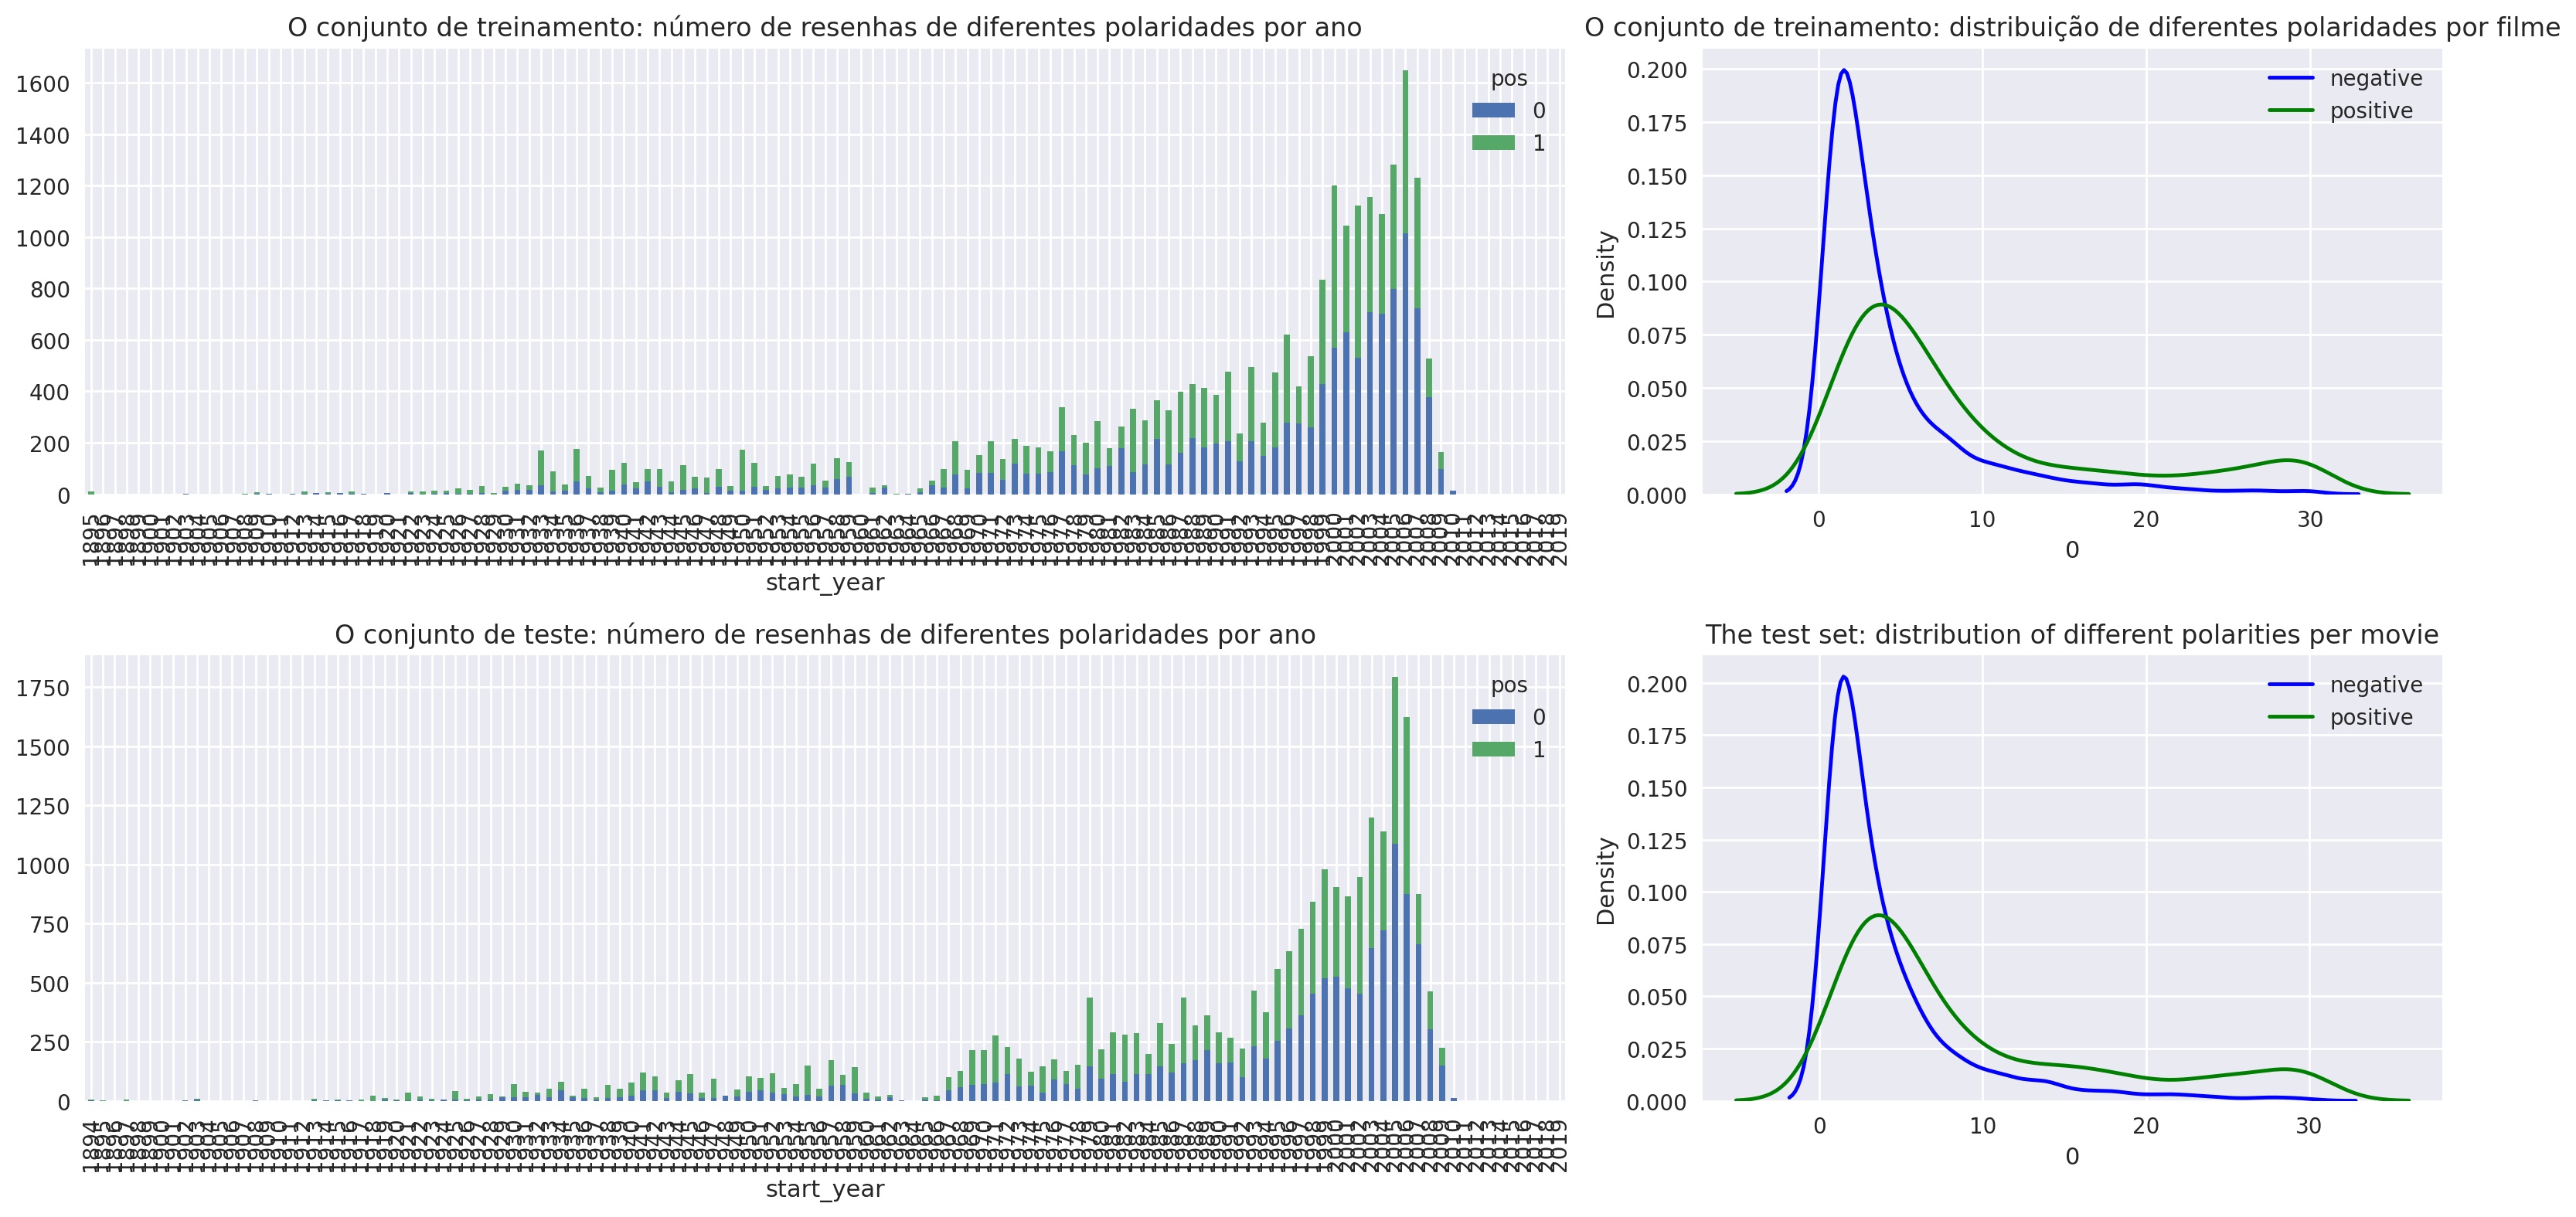

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

**Conclusão da AED.**

- O conjunto está **equilibrado quanto à polaridade**: aproximadamente 23,7 mil resenhas negativas (`pos=0`) e 23,6 mil positivas (`pos=1`), sem desequilíbrio de classe relevante. Isso justifica usar o **F1** como métrica sem precisar de reamostragem.
- As divisões de **treino e teste** têm tamanhos semelhantes (~23,8 mil e ~23,5 mil) e distribuições de classificação (`rating`) e de polaridade ao longo dos anos muito parecidas entre si — não há desvio evidente entre os conjuntos.
- Note a **ausência de notas 5 e 6**: o critério de rotulagem do IMDB considera negativas as resenhas com nota ≤ 4 e positivas as com nota ≥ 7, deixando de fora as notas neutras.
- O volume de resenhas cresce fortemente a partir dos anos 2000, e a maioria dos filmes tem poucas resenhas (a distribuição por filme é assimétrica à direita).

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [48]:

import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Acurácia'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [49]:
import re

def normalize_text(text):
    # converte para minúsculas
    text = text.lower()
    # mantém apenas letras latinas, apóstrofos e espaços; o resto vira espaço
    text = re.sub(r"[^a-z' ]", ' ', text)
    # remove espaços extras
    text = ' '.join(text.split())
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

df_reviews[['review', 'review_norm']].head()

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [50]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

Como linha de base, usamos um classificador que sempre prevê a classe mais frequente. Serve de referência mínima: qualquer modelo útil deve superá-lo com folga.

In [51]:
from sklearn.dummy import DummyClassifier

In [52]:
model_0 = DummyClassifier(strategy='most_frequent')

In [53]:
model_0.fit(df_reviews_train[['review_norm']], train_target)

DummyClassifier(strategy='most_frequent')

In [54]:
test_pred_0 = model_0.predict(df_reviews_test[['review_norm']])

print('Acurácia:', metrics.accuracy_score(test_target, test_pred_0))
print('F1:', metrics.f1_score(test_target, test_pred_0))

Acurácia: 0.5015083917569577
F1: 0.0


O modelo constante atinge acurácia ≈ 0,50 e **F1 = 0,00** (o baseline sempre prevê a classe negativa, que é ligeiramente majoritária). Confirma que o problema não é trivial e estabelece o piso de desempenho.

### Modelo 1 - NLTK, TF-IDF e Regressão Logística

TF-IDF

In [55]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [56]:
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = list(stopwords.words('english'))

tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stop_words)

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

print('Formato das características de treino:', train_features_1.shape)
print('Formato das características de teste:', test_features_1.shape)

Formato das características de treino: (23796, 71531)
Formato das características de teste: (23535, 71531)


In [57]:
model_1 = LogisticRegression(max_iter=1000, random_state=12345)
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

          train  test
Acurácia   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


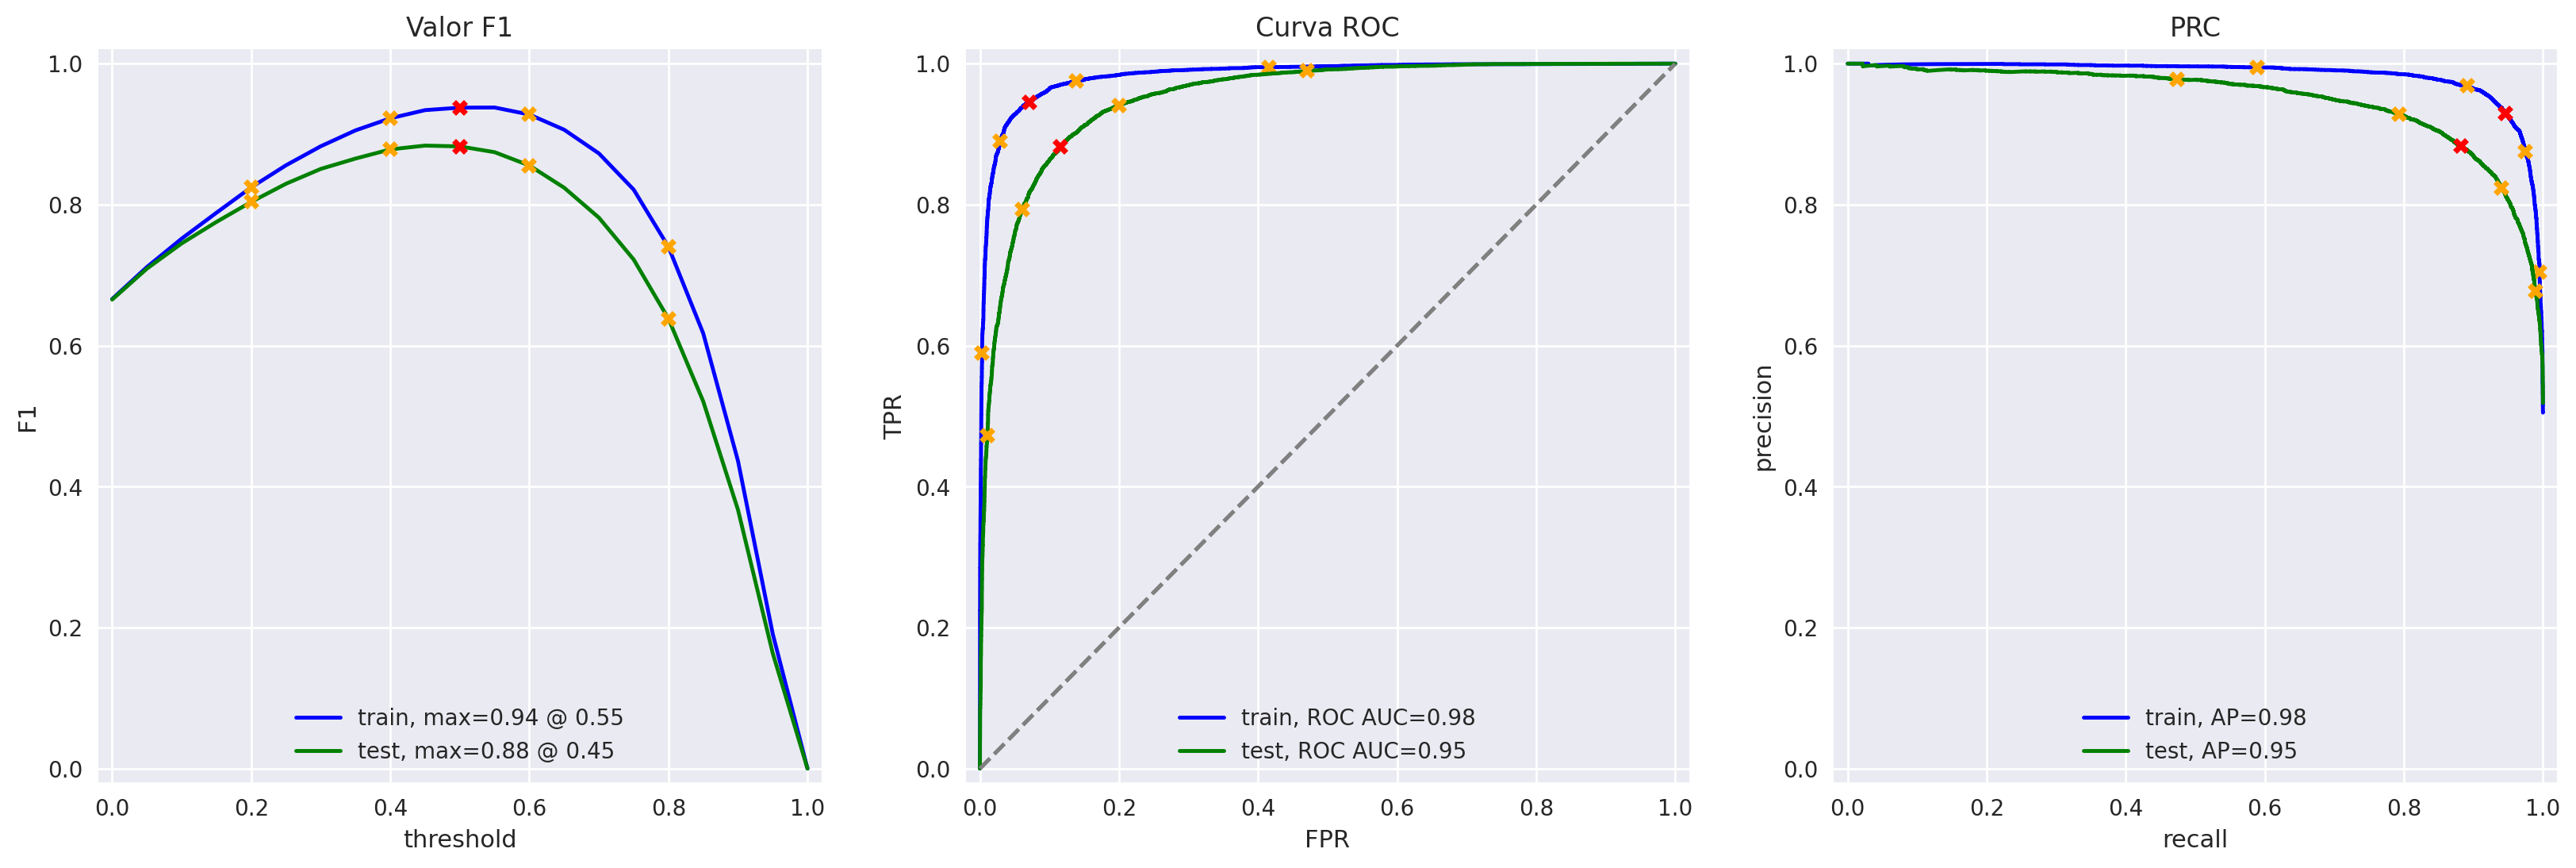

In [58]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 3 - spaCy, TF-IDF e Regressão Logística

In [59]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [60]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [61]:
# Lematização das resenhas (pode levar alguns minutos)
df_reviews_train['review_lemm'] = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
df_reviews_test['review_lemm'] = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

In [62]:
tfidf_vectorizer_3 = TfidfVectorizer(stop_words=stop_words)

train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_lemm'])
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_lemm'])

print('Formato das características de treino:', train_features_3.shape)
print('Formato das características de teste:', test_features_3.shape)

Formato das características de treino: (23796, 59139)
Formato das características de teste: (23535, 59139)


In [63]:
model_3 = LogisticRegression(max_iter=1000, random_state=12345)
model_3.fit(train_features_3, train_target)

LogisticRegression(max_iter=1000, random_state=12345)

          train  test
Acurácia   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


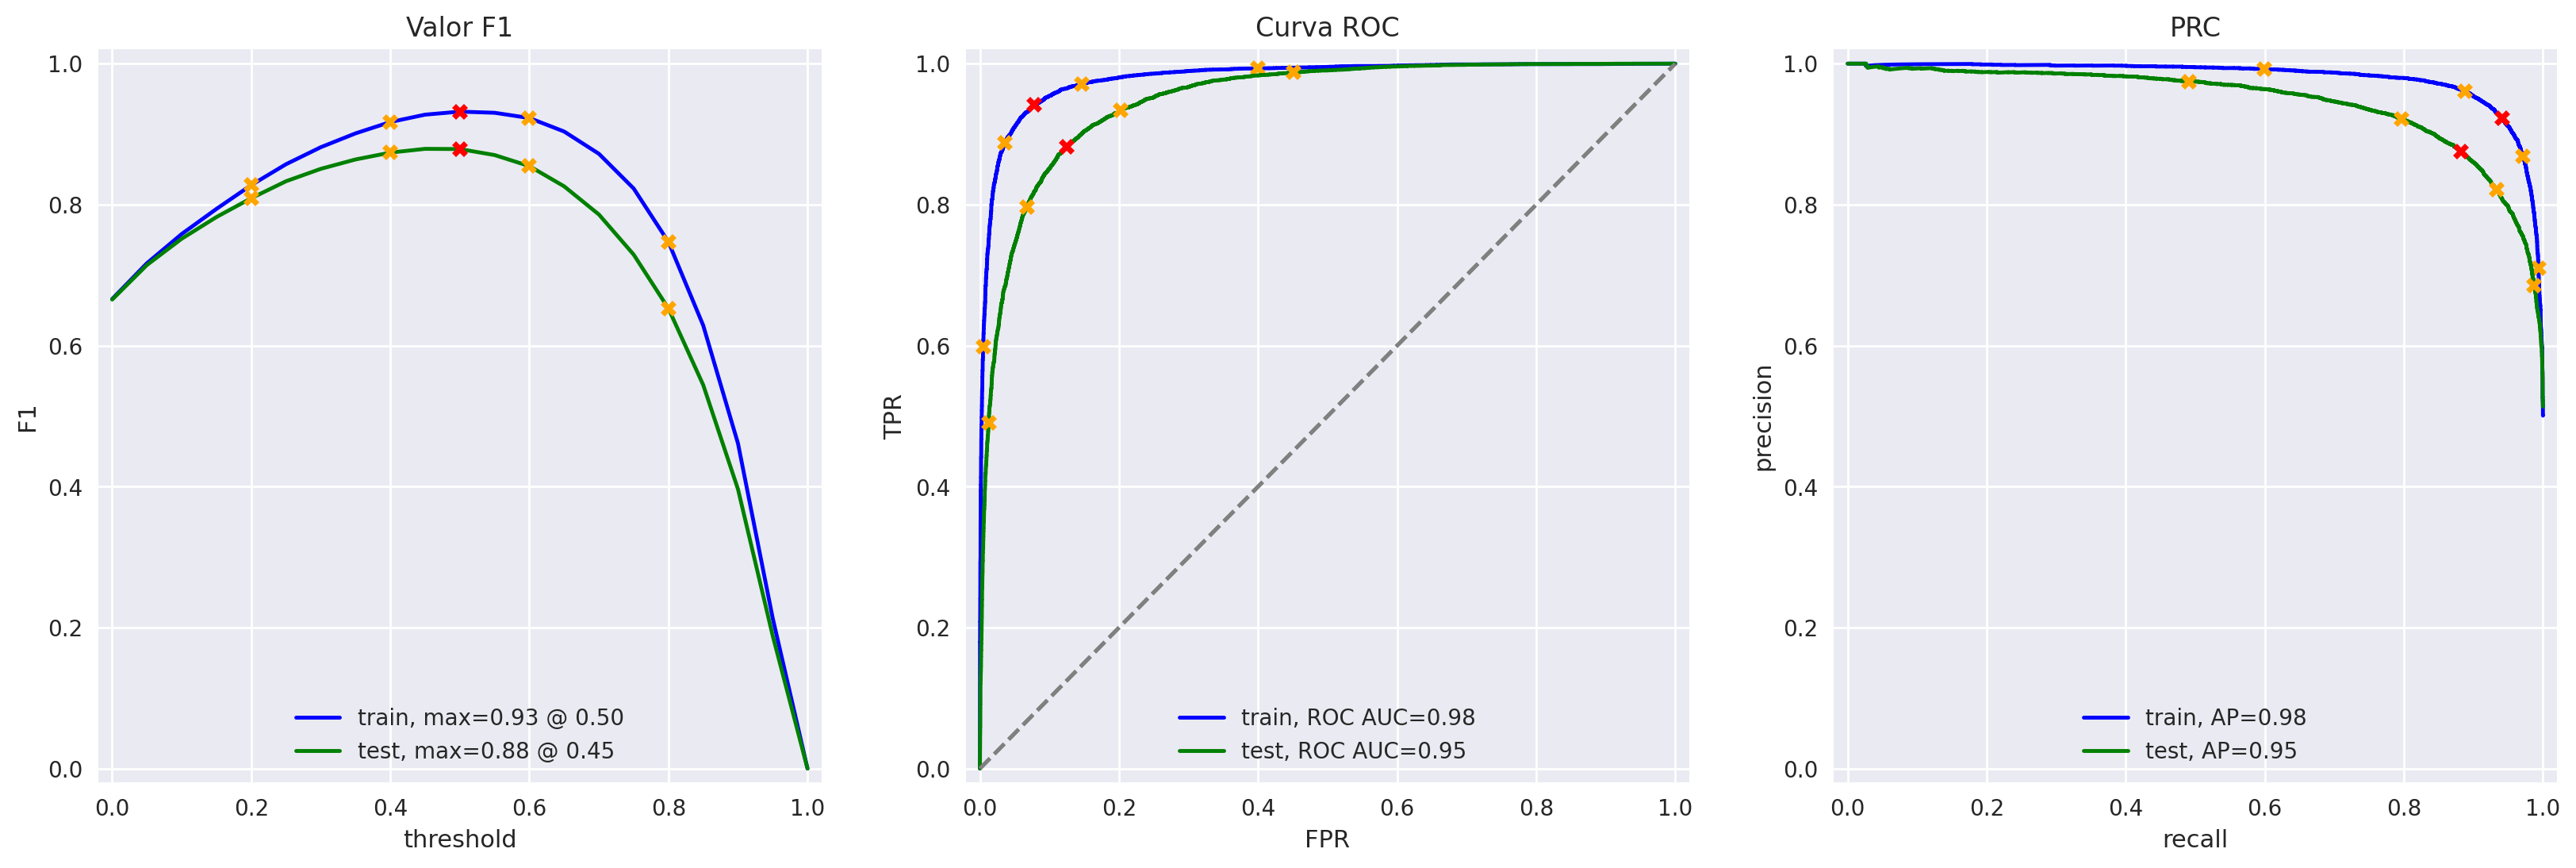

In [64]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [65]:
from lightgbm import LGBMClassifier

In [66]:
# Reutilizamos as características TF-IDF lematizadas do Modelo 3
tfidf_vectorizer_4 = tfidf_vectorizer_3
train_features_4 = train_features_3
test_features_4 = test_features_3

In [67]:
model_4 = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=-1,
    random_state=12345,
    n_jobs=-1,
)
model_4.fit(train_features_4, train_target)

LGBMClassifier(n_estimators=500, random_state=12345)

          train  test
Acurácia    1.0  0.87
F1          1.0  0.87
APS         1.0  0.94
ROC AUC     1.0  0.95


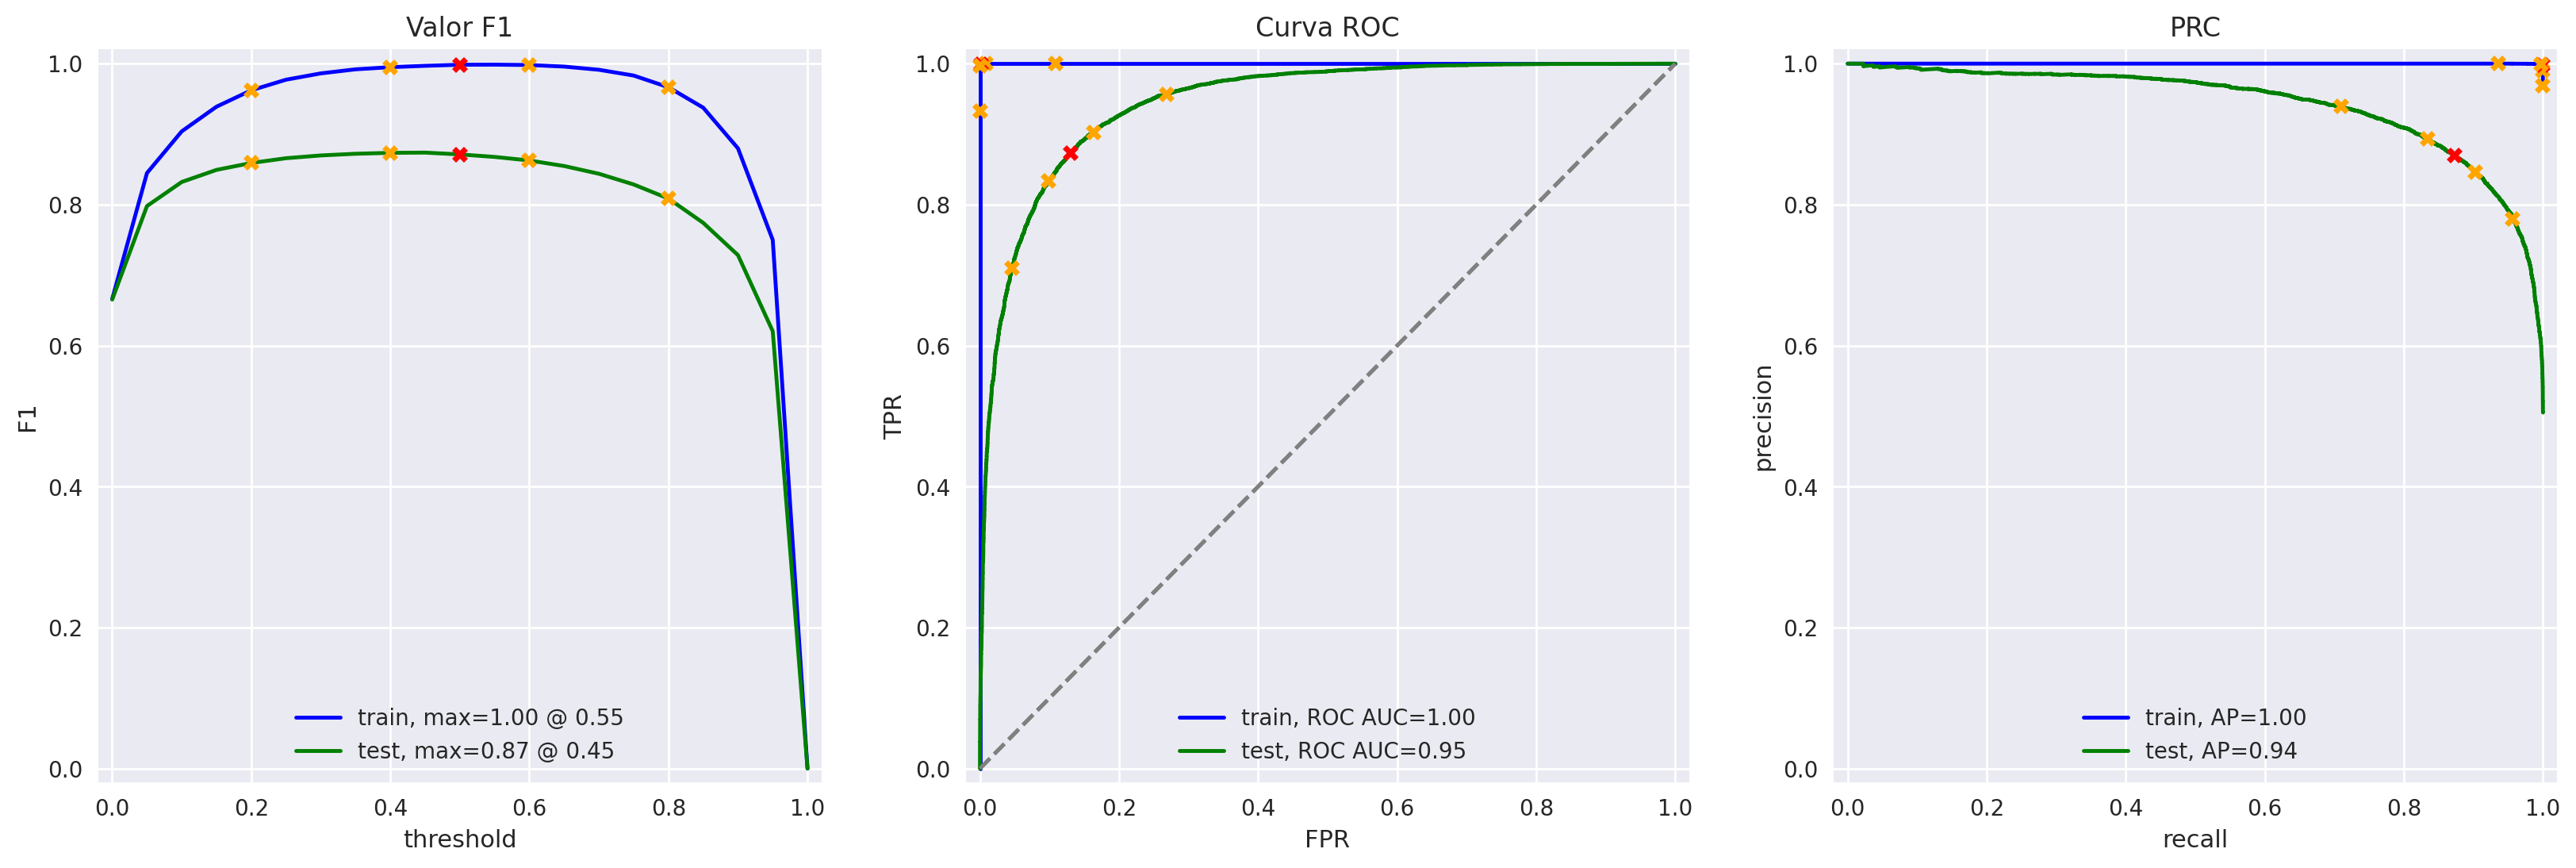

In [68]:
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

### Modelo 9 — BERT (experimento opcional)

A tentativa original não concluiu por ausência de GPU; não há F1 de BERT validado neste arquivo. Ative `RUN_BERT` somente se quiser executar o experimento. O modelo é obtido de `bert-base-uncased` e requer download e recursos adicionais.

In [69]:
RUN_BERT = False

if RUN_BERT:
    import torch
    import transformers

In [ ]:
if RUN_BERT:
    tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
    config = transformers.BertConfig.from_pretrained('bert-base-uncased')
    model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [ ]:
if RUN_BERT:
    def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
        
        ids_list = []
        attention_mask_list = []
    
        # texto para IDs de tokens preenchidos com suas máscaras de atenção
        for text in texts:
            encoded = tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                truncation=True,
                max_length=max_length,
                padding='max_length',
                return_attention_mask=True,
            )
            ids_list.append(encoded['input_ids'])
            attention_mask_list.append(encoded['attention_mask'])
        
        if force_device is not None:
            device = torch.device(force_device)
        else:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        model.to(device)
        if not disable_progress_bar:
            print(f'Usando o dispositivo {device}.')
        
        # recebendo incorporações em lotes    
        embeddings = []
    
        for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
                
            ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
            attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
                
            with torch.no_grad():            
                model.eval()
                batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
            embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
            
        return np.concatenate(embeddings)

In [ ]:
if RUN_BERT:
    # Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
    # Por isso, tomamos uma amostra reduzida de cada parte
    N_BERT = 500
    
    df_reviews_train_bert = df_reviews_train.sample(N_BERT, random_state=12345).reset_index(drop=True)
    df_reviews_test_bert = df_reviews_test.sample(N_BERT, random_state=12345).reset_index(drop=True)
    
    train_target_bert = df_reviews_train_bert['pos']
    test_target_bert = df_reviews_test_bert['pos']
    
    train_features_9 = BERT_text_to_embeddings(df_reviews_train_bert['review_norm'], force_device=None)
    test_features_9 = BERT_text_to_embeddings(df_reviews_test_bert['review_norm'], force_device=None)

In [ ]:
if RUN_BERT:
    print(train_features_9.shape)
    print(train_target_bert.shape)

In [74]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

In [ ]:
if RUN_BERT:
    model_9 = LogisticRegression(max_iter=1000, random_state=12345)
    model_9.fit(train_features_9, train_target_bert)

In [ ]:
if RUN_BERT:
    evaluate_model(model_9, train_features_9, train_target_bert, test_features_9, test_target_bert)

## Minhas Resenhas

In [76]:
# Exemplos de resenhas para inspeção qualitativa; não constituem um teste rotulado.

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, not even kids will like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting and intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


### Modelo 1

In [77]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.14:  i did not simply like it not my kind of movie
0.16:  well i was bored and felt asleep in the middle of the movie
0.54:  i was really fascinated with the movie
0.11:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.31:  i didn't expect the reboot to be so good writers really cared about the source material
0.47:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud not even k
0.82:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Modelo 3

In [79]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.20:  i did not simply like it not my kind of movie
0.12:  well i was bored and felt asleep in the middle of the movie
0.49:  i was really fascinated with the movie
0.10:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.27:  i didn't expect the reboot to be so good writers really cared about the source material
0.50:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud not even k
0.92:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Modelo 4

In [80]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.44:  i did not simply like it not my kind of movie
0.21:  well i was bored and felt asleep in the middle of the movie
0.55:  i was really fascinated with the movie
0.15:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.42:  i didn't expect the reboot to be so good writers really cared about the source material
0.79:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.19:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud not even k
0.95:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Modelo 9

In [ ]:
if RUN_BERT:
    texts = my_reviews['review_norm']
    
    my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)
    
    my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]
    
    for i, review in enumerate(texts.str.slice(0, 100)):
        print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Conclusões

**Objetivo.** Construir um classificador de polaridade de resenhas do IMDB para a Film Junky Union, com meta de **F1 ≥ 0,85** no conjunto de teste.

**AED.** O conjunto é equilibrado entre resenhas positivas e negativas (~23,6k vs ~23,7k), com divisões treino/teste de tamanho e distribuição semelhantes. Não há desequilíbrio de classe a corrigir, e as notas neutras (5 e 6) estão ausentes por construção da rotulagem.

**Modelos treinados e resultados de F1 no teste:**

| Modelo | Pré-processamento | Vetorização | Classificador | F1 (teste) |
|---|---|---|---|---:|
| 0 | — | — | DummyClassifier | 0,00 |
| 1 | Normalização e stopwords NLTK | TF-IDF | Regressão Logística | **0,88** |
| 3 | Lematização spaCy | TF-IDF | Regressão Logística | **0,88** |
| 4 | Lematização spaCy | TF-IDF | LightGBM | **0,87** |
| 9 | BERT, amostra de 500 por divisão | Embedding CLS | Regressão Logística | Sem resultado validado |

**Comparação e escolha.** Os três modelos TF-IDF superam a meta de 0,85. A regressão logística do Modelo 1 combina F1 0,88 e ROC-AUC 0,95 com pré-processamento simples, sem a etapa adicional de lematização. Tempos de processamento não foram medidos de forma controlada.

**Limitações.** O conjunto já tem divisão de treino e teste. Os modelos foram comparados sobre o mesmo teste; seleção e ajuste de limiar futuros devem usar validação separada. Os exemplos de resenhas são ilustrativos, sem rótulos para medir acurácia. O experimento BERT não concluiu na execução original e não sustenta comparação de qualidade.

**Próximos passos.** Validar em novas resenhas, analisar erros e calibração, escolher limiar em validação e medir latência antes de qualquer implantação.
